<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/categorical_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D
from keras.layers import Add, Input
from keras.models import Model

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (87554, 188)


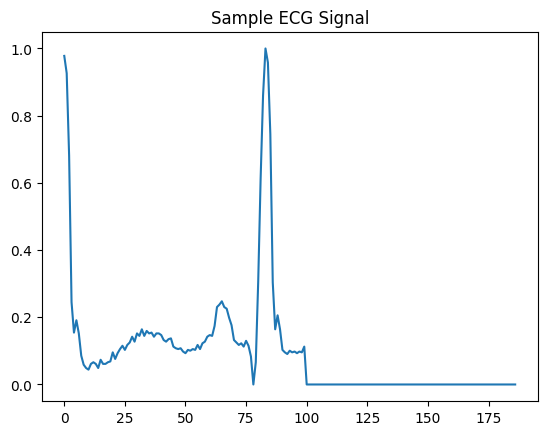

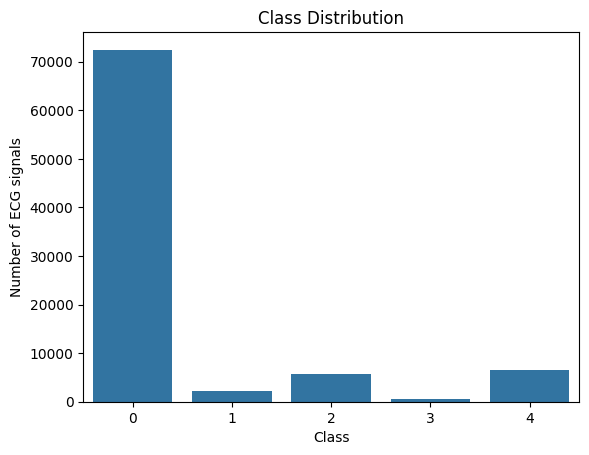

0
0


In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [6]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]


In [7]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [8]:
y_res_sparse = y_res
y_test_sparse = y_test

X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [9]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x


def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128,activation='relu')(x)
    outputs = Dense(5,activation='softmax')(x)

    model = Model(inputs,outputs)

    model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # ✅ THIS is the replacement
    metrics=['accuracy']
)

    return model



In [13]:
y_train_final = tf.keras.utils.to_categorical(y_train_final, 5)
y_val_final   = tf.keras.utils.to_categorical(y_val_final, 5)

In [14]:
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res_sparse)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]

    y_tr = tf.keras.utils.to_categorical(y_res_sparse.iloc[train_idx], 5)
    y_va = tf.keras.utils.to_categorical(y_res_sparse.iloc[val_idx], 5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.9449 - loss: 0.1579
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9782 - loss: 0.0635
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9862 - loss: 0.0402
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9905 - loss: 0.0285
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9926 - loss: 0.0223
Fold 1 Accuracy: 0.9291

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.9452 - loss: 0.1559
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9788 - loss: 0.0617
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9868 - loss: 0.0391
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.9906 - loss: 0.0280
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9928 - loss: 0.0217
Fold 2 Accuracy: 0.7643

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 49s 1

In [15]:
from tensorflow.keras.utils import to_categorical
# Reshape full SMOTE-resampled data for training
X_res_reshaped = np.array(X_res).reshape(-1, 187, 1)
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# Split for validation (optional, you can use full train data too)
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res_reshaped, y_res_cat, test_size=0.2, random_state=42
)

In [16]:
# Create the ResNet model
model = resnet_ecg()

# Train the model
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 67s 12ms/step - accuracy: 0.9502 - loss: 0.1429 - val_accuracy: 0.9577 - val_loss: 0.1189
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9812 - loss: 0.0553 - val_accuracy: 0.8985 - val_loss: 0.3123
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9882 - loss: 0.0353 - val_accuracy: 0.9629 - val_loss: 0.1085
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9913 - loss: 0.0260 - val_accuracy: 0.9896 - val_loss: 0.0319
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.9935 - loss: 0.0196 - val_accuracy: 0.9347 - val_loss: 0.2213
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9745 - val_loss: 0.0642
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9746 - val_loss: 0.0749
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9963 - los

In [17]:
# Evaluate on validation set
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)
mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step
Validation MCC: 0.9950714153835369


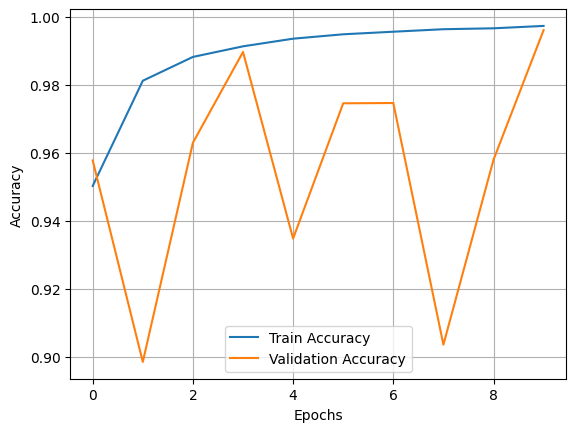

In [18]:
# Plot training/validation accuracy
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

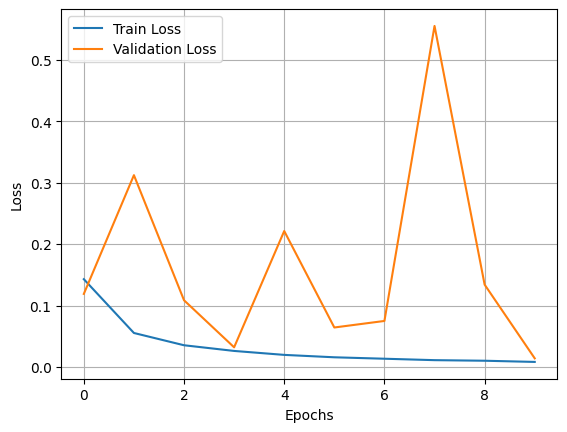

In [19]:
# Plot training/validation loss
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [20]:
# Final training & validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Final Training Accuracy: 0.9973
Final Validation Accuracy: 0.9961
Final Training Loss: 0.0081
Final Validation Loss: 0.0139


In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Test set classification report
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

Test Loss: 0.0222
Test Accuracy: 0.9927
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     72471
         1.0       0.84      0.99      0.91      2223
         2.0       0.99      1.00      0.99      5788
         3.0       0.95      0.98      0.96       641
         4.0       1.00      1.00      1.00      6431

    accuracy                           0.99     87554
   macro avg       0.95      0.99      0.97     87554
weighted avg       0.99      0.99      0.99     87554



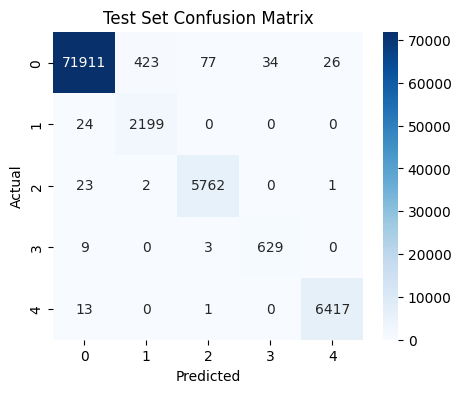

In [22]:
# Confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.show()